***Session 3: Statistical Testing***

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Image
import seaborn as sns
import scipy.stats as stats 
import pandas as pd
import numpy as np

### This is some configuration to make the plots work better when presenting online
import matplotlib.pylab as pylab
pylab.rcParams['figure.figsize'] = 6, 6
plt.rc("font", size=16)

Now that we have seen the basis of statistical hypothesis testing, let's review some of the most used ones.

# Fisher's exact test and the Chi-squared test

These two tests aim to discover the association between 2 categorical variables.

Their **null hypothesis** is the absence of association between the two variables.


**Fisher's exact test**, as its name entails, computes a p-value which is exact, even for very low sample sizes. However, it becomes computationally complex to compute as the dataset size or the number of categories gets higher.

The **Chi-squared test**, in contrast, uses an approximation of the exact p-value, which is only valid when samples are big enough. However, it scales well to larger sample sizes and number of categories.


Both tests start from a **contingency table**.

We are going to use as an example the historical [Lady tasting tea](https://en.wikipedia.org/wiki/Lady_tasting_tea).

|  | detected as milk before | detected as milk after | marginal sums |
|---|---|---|---|
| **milk before** | 3 | 1 | **4** |
| **milk after** | 1 | 3 | **4** |
| **marginal sums**  | **4** | **4** | **8** |

In our experiment, the lady was able to correctly identify 6 out of 8 cups.


## Fisher's exact test

The test is based on counting the number of possible tables that have the same marginal sums.

The p-value corresponds to the number of tables as extreme or more extreme than the observed one, divided by the total number of tables.

Given the constraint of keeping the marginal sums, describing the number of *correctly detected cups with the milk before* suffices to describe a type of table.

In our case, tables as extreme or more extreme than the observed ones are the ones where the number of correctly detected cups with the milk before is:
* 3 : 16 tables :
     * 4 ways of selecting 3 cups with milk before correctly
     * 4 ways of selecting 3 cups with milk after correctly
* 1 : 16 tables :
     * 4 ways of selecting 1 cups with milk before correctly
     * 4 ways of selecting 1 cups with milk after correctly
* 4 : 1 table (1x1)
* 0 : 1 table (1x1)


There is also another possible case; however, this one is less extreme than the observed case:
* 2 : 36 tables :
     * 6 ways of selecting 2 cups with milk before correctly
     * 6 ways of selecting 2 cups with milk after correctly


Given that there are 70 (16+16+1+1+36) possible tables in total here, the p-value is $(16+1+1+16)/70 \approx 0.486$

> Note : by defining more extreme tables as the ones where there are as many or more successes than observed, we would effectively be performing a 1-sided test.

While it is fun to use combinatorics to compute p-values, `scipy` has a function for it:

In [2]:
table = [[3,1],[1,3]]

oddsratio, pvalue = stats.fisher_exact(table)
print("Fisher's exact test")
print('\todds ratio:', oddsratio)
print('\tp-value:', pvalue)

Fisher's exact test
	odds ratio: 9.0
	p-value: 0.48571428571428565


The odds ratio corresponds to the product of the row-wise odds (i.e., number correct guess divided by number of wrong guesses):

$$\frac{3}{1} * \frac{3}{1} = 9$$

## Chi-squared

The Chi-squared test is based on an approximation, 
which works best when the expected **number of observations in each cell exceeds 5**.

Nevertheless, we can still compute the test statistic for our *simple* example.

The idea of the test is that, under the null hypothesis that the two variables are not linked, the expected values in each cell of the table can be deduced solely from the marginal sums.

In our case that gives the folowing expected table:

|  | detected as milk before | detected as milk after | marginal sums |
|---|---|---|---|
| **milk before** | 8x(4/8)x(4/8)=2 | 8x(4/8)x(4/8)=2 | **4** |
| **milk after** | 8x(4/8)x(4/8)=2 | 8x(4/8)x(4/8)=2 | **4** |
| **marginal sums**  | **4** | **4** | **8** |

> Sure, our example is a bit boring here.

Then, the test statistic of the test :

$$T = \sum \frac{(observed-expected)^2}{expected}$$

For our example, 

$$ T = \frac{(3-2)^2}{2} +\frac{(1-2)^2}{2} + \frac{(1-2)^2}{2} +\frac{(3-2)^2}{2} = 2$$


Which is expected to follow a $\chi^2$ (chi-square) distribution with a number of degree of freedom equal to:

$$ df = (\text{number of columns} - 1) * (\text{number of rows} - 1) $$

In our case $df=(2-1)*(2-1)=1$

> Note: this is directly related to the Fisher's exact test where we could describe tables using a single value

In [3]:
chi2, pval, df, expected = stats.chi2_contingency(table, correction=False)
print("Chi-squared test")
print('\tchi2:', chi2)
print('\tdf:', df)
print('\tp-value:', pval)

Chi-squared test
	chi2: 2.0
	df: 1
	p-value: 0.15729920705028105


In [4]:
table

[[3, 1], [1, 3]]

In [5]:
expected

array([[2., 2.],
       [2., 2.]])

You can see here that the returned p-value is quite different from the one given by Fisher's exact test.

> Note that here we use `correction=False` as by default scipy implementation uses [Yates's correction](https://en.wikipedia.org/wiki/Yates%27s_correction_for_continuity), which is useful when the effectives are low. Try the same lines with the correction to see the difference.



Let's imagine now that we have a many cups and very patient lady so that the contigency table looks like this:

|  | detected as milk before | detected as milk after | marginal sums |
|---|---|---|---|
| **milk before** | 25 | 15 | **40** |
| **milk after** | 18 | 22 | **40** |
| **marginal sums**  | **43** | **37** | **80** |



In [6]:
table = [[25,15],[18,22]]

oddsratio, pvalue = stats.fisher_exact(table)
print("Fisher's exact test")
print('\todds ratio:', oddsratio)
print('\tp-value:', pvalue)

chi2, pval, df, expected = stats.chi2_contingency(table, correction=False)
print("Chi-squared test")
print('\tchi2:', chi2)
print('\tp-value:', pval)

Fisher's exact test
	odds ratio: 2.037037037037037
	p-value: 0.17815079712391602
Chi-squared test
	chi2: 2.4638592080452546
	p-value: 0.11649225257988546


In [7]:
expected

array([[21.5, 18.5],
       [21.5, 18.5]])

You can see that the p-value of the Chi-squared test is now much closer to that of Fisher's exact test.

## Exercise 01

Come back to the census data from 1880, in particular the `'data/census1880_fractions.csv'` file we saved.

1. Test the association between majority religion (`'majority_religion'`) and majority language (`'majority_language'`).

> Tip: to create a contingency table :

> ```table = pd.crosstab( dfFractions['majority religion'] , dfFractions['majority language'] )```


2. Which test is appropriate to use here? Explain why.

In [8]:
dfFractions = pd.read_csv('data/census1880_fractions.csv')
dfFractions.head()

,Unnamed: 0,town name,canton,canton name,Total,Swiss,Foreigner,Male,Female,0-14 y.o.,...,Reformed,Catholic,Other,German speakers,French speakers,Italian speakers,Romansche speakers,Non-national tongue speakers,majority religion,majority language
0,0,Aeugst,ZH,Zürich,646,0.970588,0.029412,0.493808,0.506192,0.335913,...,0.910217,0.066563,0.023220,0.998452,0.000000,0.001548,0.0,0.000000,Reformed,German speakers
1,1,Affoltern am Albis,ZH,Zürich,2201,0.948660,0.051340,0.479328,0.520672,0.323944,...,0.882326,0.098137,0.019537,0.996365,0.002272,0.001363,0.0,0.000000,Reformed,German speakers
2,2,Bonstetten,ZH,Zürich,771,0.977951,0.022049,0.468223,0.531777,0.345006,...,0.968872,0.025940,0.005188,1.000000,0.000000,0.000000,0.0,0.000000,Reformed,German speakers
3,3,Hausen,ZH,Zürich,1363,0.957447,0.042553,0.469552,0.530448,0.251651,...,0.928833,0.069699,0.001467,0.984593,0.008804,0.006603,0.0,0.000000,Reformed,German speakers
4,4,Hedingen,ZH,Zürich,907,0.955899,0.044101,0.493936,0.506064,0.281147,...,0.949283,0.048512,0.002205,0.984564,0.000000,0.009923,0.0,0.005513,Reformed,German speakers


In [9]:
table = pd.crosstab(dfFractions['majority religion'], dfFractions['majority language'])
table

majority language,French speakers,German speakers,Italian speakers,Romansche speakers
majority religion,,,,
Catholic,426,693,286,58
Reformed,503,1155,6,63


In [10]:
# Create a solution here:


In [11]:
# %load solutions/solution_03_01.py
## Chi-squared test
chi2, pval, df, expected = stats.chi2_contingency(table, correction=False)
print("Chi-squared test")
print('\tchi2:', chi2)
print('\tp-value:', pval)

## Fisher's exact test
oddsratio, pvalue = stats.fisher_exact(table)
print("Fisher's exact test")
print('\todds ratio:', oddsratio)
print('\tp-value:', pvalue)

## Both tests can be used here. 
## Fisher's will be more accurate but more computationally expensive; on the other hand, 
## Chi-squared will be quicker, computationally less expensive, but only approximate, not exact.

Chi-squared test
	chi2: 371.2764863992308
	p-value: 3.683741749850483e-80
Fisher's exact test
	odds ratio: 2.4603300740077337e-101
	p-value: 0.0001


# Kolmogorov-Smirnov test

The Kolmogorov-Smirnov is a **nonparametric test that compares entire distributions**.
It can either be used to compare the distribution of samples, or the distribution of a single sample with a distribution of reference.

Contrary to the t-test which is only a test of location, the **KS test also differentiate differences in scale and shape**.

The statistic of the Kolmogorov-smirnov test corresponds to the maximal distance between the cumulative distribution functions of the sample and the reference distribution (1-sample test) or the second sample (2-sample test)

K-S statistic:  0.12510410858998622


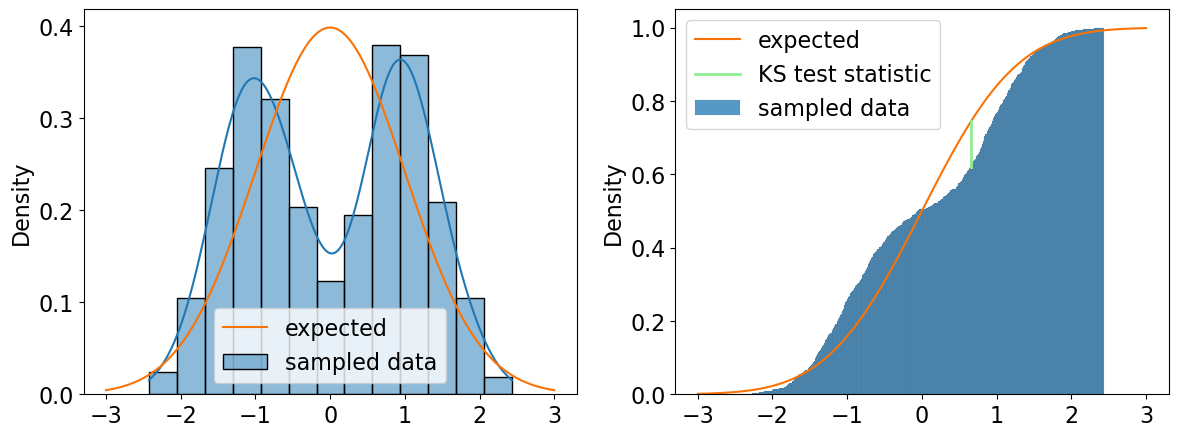

In [12]:
# creating a bimodal distribution of sample size 1000
sampleSize = 1000
sample = np.random.randn(sampleSize) * 0.5 + 1 - 2 * (np.random.random(sampleSize) > 0.5) 

# computing the observed CDF and comparing with what is expected under a normal distribution
sample.sort()
cdfobserved = np.arange(1, len(sample) + 1) / len(sample)
cdfexpected = stats.norm.cdf(sample)

diff = abs(cdfexpected - cdfobserved)
positionMax = np.argmax(diff) 
maxDiff = diff[positionMax]
maxPos = sample[positionMax]

print('K-S statistic: ', maxDiff)

# plotting the pdf and cdf 
x = np.linspace(-3, 3, 100)
fig,axes = plt.subplots(1, 2, figsize=(14,5))

# Plot 1
sns.histplot(sample, label='sampled data', stat='density', kde=True, ax = axes[0])
sns.lineplot(x=x, y=stats.norm.pdf(x), color='xkcd:orange', label='expected', ax = axes[0])

# Plot 2
sns.histplot(sample, bins = len(sample), stat='density', cumulative=True, label='sampled data', ax = axes[1]).set_zorder(1)
sns.lineplot(x=x, y=stats.norm.cdf(x), color='xkcd:orange', label='expected', ax = axes[1])

# adding a segment to visualize the KS statistic in plot 2
axes[1].plot([maxPos, maxPos], [cdfobserved[positionMax], cdfexpected[positionMax]],
             color='lightgreen', linewidth = 2, label ='KS test statistic')
axes[1].legend()
plt.show()

In [13]:
# test :
ksStat, pvalue = stats.kstest(sample, stats.norm.cdf)
print('1-sample Kolmogorov-Smirnov test:')
print('KS test statistic :', ksStat)
print('p-value :', pvalue)

1-sample Kolmogorov-Smirnov test:
KS test statistic : 0.12610410858998622
p-value : 2.5450215540848177e-14


And for 2 samples:

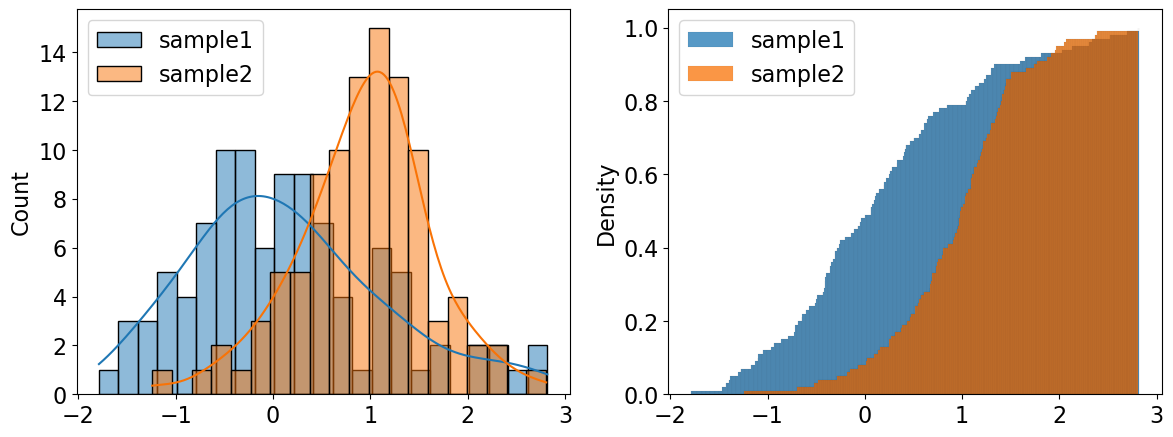

In [14]:
# simulating samples
sampleSize = 100
sample1 = np.random.randn(sampleSize) * 1 
sample2 = np.random.randn(sampleSize) * 0.6 + 1.0

# plotting the pdf and cdf 
fig,axes = plt.subplots(1, 2, figsize=(14,5))

# Plot 1
sns.histplot(sample1, label='sample1', binwidth=0.2, kde=True, ax = axes[0])
sns.histplot(sample2, label='sample2', binwidth=0.2, color='xkcd:orange', kde=True, ax = axes[0])
axes[0].legend()

# Plot 2
sns.histplot(sample1, bins = len(sample), stat='density', cumulative=True, kde=False, label='sample1', ax = axes[1])
sns.histplot(sample2, bins = len(sample), stat='density', cumulative=True, color='xkcd:orange', kde=False, label='sample2', ax = axes[1])
axes[1].legend()
plt.show()

In [15]:
# test :
ksStat, pvalue = stats.ks_2samp(sample1, sample2)
print('1-sample Kolmogorov-Smirnov test:')
print('KS test statistic :', ksStat)
print('p-value :', pvalue)

1-sample Kolmogorov-Smirnov test:
KS test statistic : 0.49
p-value : 2.948425133635738e-11


The Kolmogorov-Smirnov is very useful because it is non parametric (i.e., less assumptions to check) and it accounts for variations in general and not only in location.

The reason we keep using the t-test when we want to compare locations is because the **KS test has a worse statistical power than the t-test**:

In [16]:
# define samples and simulation parameters
sampleSize = 10
diff = 1.0
sigThreshold = 0.05
N = 1000

# variables to store the results
rejectedKS = 0
rejectedT = 0

# loop for simulation
for i in range(N):
    sample1 = np.random.randn(sampleSize) 
    sample2 = np.random.randn(sampleSize) + diff
    
    ## Is the KS test able to find the difference?
    ksStat, pvalue = stats.ks_2samp(sample1, sample2)
    if pvalue <= sigThreshold:
        rejectedKS += 1
    
    ## Is the t-test able to find the difference?
    tstat, pvalue = stats.ttest_ind(sample1, sample2)
    if pvalue <= sigThreshold:
        rejectedT += 1

print("Power for a difference in mean", diff, ', sample size', sampleSize, 'and significance threshold', sigThreshold)
print('KS test', rejectedKS / N * 100, '%')
print('T test ', rejectedT / N * 100, '%')

Power for a difference in mean 1.0 , sample size 10 and significance threshold 0.05
KS test 22.900000000000002 %
T test  56.2 %


This is the case as well with tests of normality such as the Shapiro-Wilk test.

> You can think of it as the KS test being more generalistic, and performing a bit worse than specialised tests in their respective areas

## Exercise 02

In a previous exercise we used the t-test to detect a difference in the weight of mice subjected to different diets. This dataset presents another condition : `'genotype'`

Use the Kolmogorov-Smirnov test to determine if the distributions of mice weights differ between wild-type (`'WT'`) and mutant (`'KO'`) individuals.

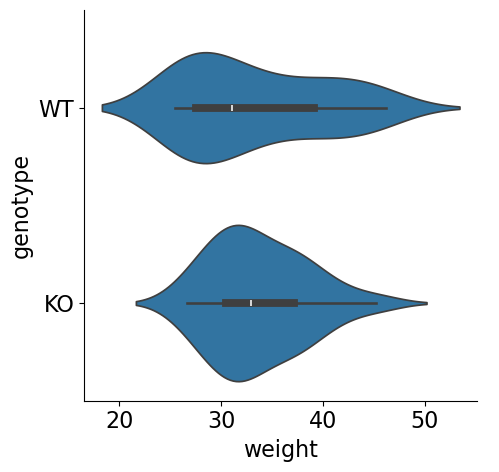

In [17]:
mice_data = pd.read_csv('data/mice_data.csv') # data about the weight of mices of different genotypes and subjected to different diets
sns.catplot(x='weight', y='genotype', data=mice_data, kind='violin')
plt.show()

In [18]:
# Create a solution here:


In [19]:
# %load solutions/solution_03_02.py
wt = mice_data[mice_data.genotype == 'WT']['weight']
ko = mice_data[mice_data.genotype == 'KO']['weight']

ksStat, pvalue = stats.ks_2samp(wt, ko)
print('1-sample Kolmogorov-Smirnov test:')
print('KS test statistic :', ksStat)
print('p-value :', pvalue)

1-sample Kolmogorov-Smirnov test:
KS test statistic : 0.26282051282051283
p-value : 0.2892677124270361


# Bartlett's test - testing variance equality

We have seen with the t-test how to check for mean equality. 
There are also tests to assess the equality of variance between different samples (also referred to as *homoscedasticity*).
Bartlett's test is one such test.

**Assumptions:** Bartlett's presumes that the data is normally distributed (remember Shapiro-Wilk's test in the previous notebook).

**Test hypothesis**: given $m$ groups of variances $\sigma^2_{1...m}$, , containing $n_1...m$ observations (for a total of $n$)
 * **Null hypothesis**: $H_0 = \sigma^2_1 = \sigma^2_2 = ... = \sigma^2_m$
 * **Alternative hypothesis**: At least one of these variances differs from the others

Under the null hypothesis, the test statistic $T$ (the precise statistic formula is not important) approximately follows a $\chi^2$ distribution with $m-1$ degrees of freedom.

Let's test this approximation using KS test:

Does T significantly differ from a Chi square distribution?
	p-value of KS test : 0.6342525371249546


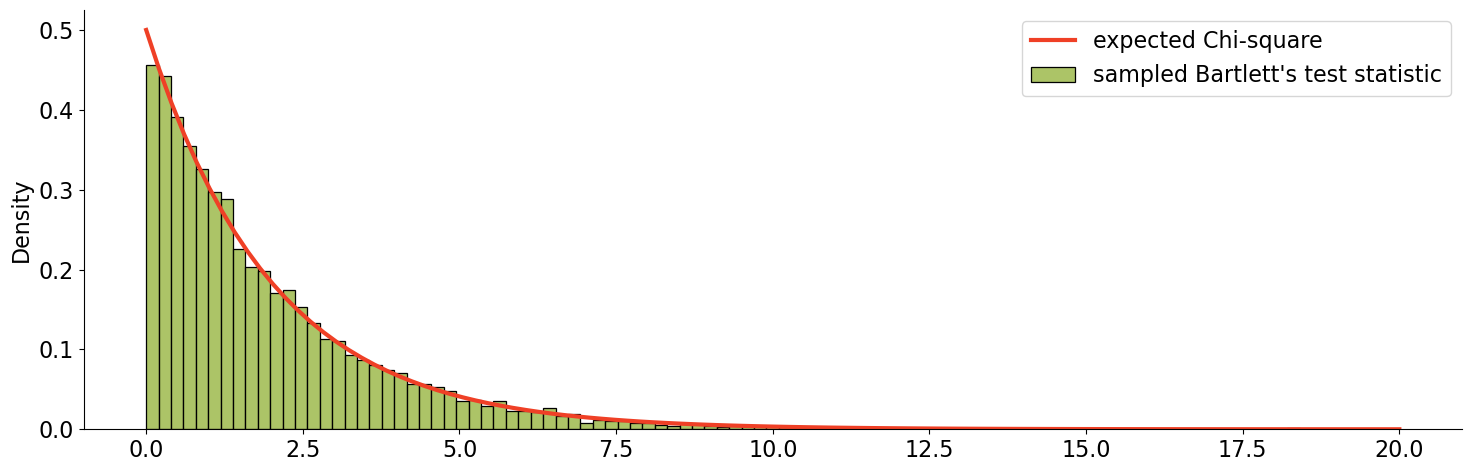

In [20]:
T = [] # list where we will store values of T under the null hypothesis
ni = 3 # number of observations per group
m = 3 # number of groups
for i in range(10000): # we run the simulation 10000 times
    samples = [np.random.randn(ni) for i in range(m)]
    stat, p = stats.bartlett(*samples)
    T.append(stat)

#performing a KS test to check if the test statistic follows the expected chi-square distribution
ksStat, pvalue = stats.kstest(T, lambda x: stats.chi2.cdf(x, df=m-1))
print('Does T significantly differ from a Chi square distribution?')
print('\tp-value of KS test :', pvalue)

sns.displot(T, color='xkcd:avocado', stat='density', aspect=3, label="sampled Bartlett's test statistic")
x = np.linspace(0, 20, 100)
sns.lineplot(x=x, y=stats.chi2.pdf(x,df=m-1), color='xkcd:tomato', linewidth=3, label="expected Chi-square")
plt.show()

The approximation seems quite valid even when $n_i$ or $m$ are low.


When the data cannot be considered normal, other tests can be used such as the **Levene test** (see [`scipy.stats.levene`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html#scipy.stats.levene))


> Note : no exercise here, but don't be afraid : you will get to apply Bartlett's test in the next exercise!

# One-way ANOVA

The ANOVA, or ANalyse Of VAriance, stands among the most used (and abused) types of statistical tests to date.

The ANOVA is used to analyze the differences among group means in a sample. 
In particular, we are going to concentrate here on the One-way ANOVA, which evaluates the difference in means of a numerical variable across groups formed by another (single) variable.

In this sense, it is a generalization of the t-test, which is limited to 2 groups only (in fact, the One-way ANOVA and t-test are equivalent when there are only 2 groups).

**ANOVA assumptions** :
* subpopulation distributions are normal
* samples have equal variances
* observations are independent from one another

**Test hypothesis** : 
given $m$ groups of mean $\bar{x}_{1...m}$, each containing $n_i$ observations (for a total of $n$)
 * **Null hypothesis** : $H_0 : \bar{x}_1 = \bar{x}_2 = ... = \bar{x}_m$
 * **Alternative hypothesis** : At least one of these means differs from the others
 
The ANOVA relies on the idea that if the mean varies between the different groups, then the overall variance of all samples should be significantly greater than the variance within each group (hence the name).

Put a bit more formally, the ANOVA is interested in the **sum of squared** differences with the mean (abbreviated SS)

> Remember that a variance is a normalised sum of squared differences from the mean


It relies on the decomposition :

$$ SS_{total} = SS_{within} + SS_{between} $$

Where:
* $ SS_{total} = \sum (x_{ij}-\bar{x})^2 $ is the sum of the SS within the full data
* $ SS_{within} = \sum (x_{ij}-\bar{x_{i}})^2 $ is the sum of the SS within each groups
* $ SS_{between} = \sum n_i * (\bar{x_{i}}-\bar{x})^2 $ is the SS between groups

If $SS_{between} >> SS_{within}$ then the grouping explain a significant part of the total variance.

The **test statistic** is:

$$ F = \frac{ SS_{between} / (m-1) }{ SS_{within} / (n-m) } $$

$(m-1)$ and $(n-m)$ correspond to the **degrees of freedom**, respectively, of the between and within group sum of squares.

Put more simply, the F statistic is a ratio of signal (biological difference) over noise (noise in data). When the ratio is high enough, we can conclude that the biological difference is significantly higher than the noise, thus there is some kind of biological relevance.

$$ \text{test statistic} \thicksim \frac{\text{signal}}{\text{noise}} \thicksim \frac{\text{var explained by the model}}{\text{var due to random errors}} \thicksim \frac{SS_{between}}{SS_{within}} $$

Under the null hypothesis the test statistic follows an F-distribution with $(m-1)$ and $(n-m)$ degrees of freedom.




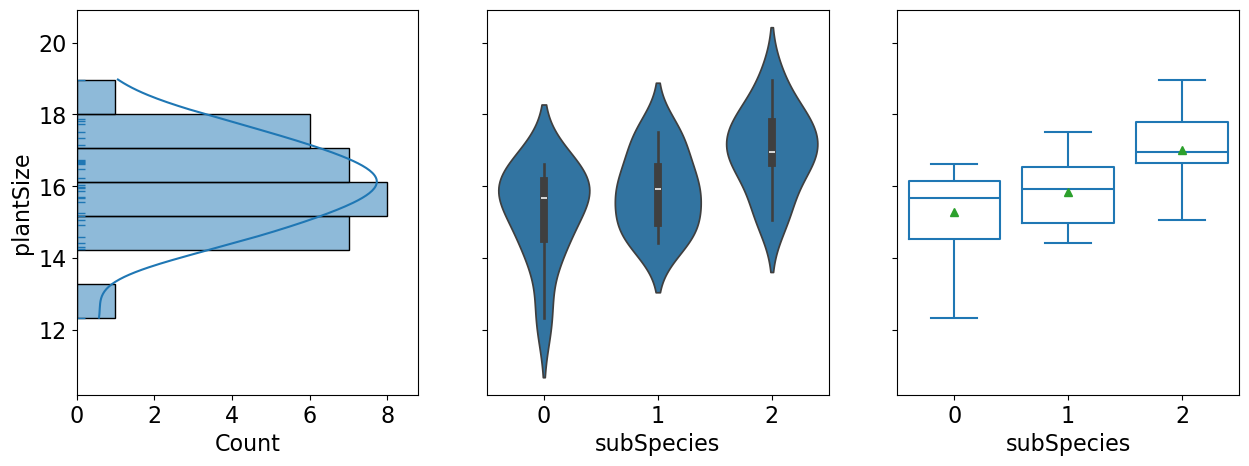

In [21]:
# we have measures of the height of the same number of individuals in 3 plant subspecies
dfPlant = pd.read_table("data/Mendaxophytae_data_oct2020.csv", sep=',')

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

sns.histplot(y=dfPlant['plantSize'], kde=True, ax = axes[0])
sns.rugplot(y=dfPlant['plantSize'],  ax = axes[0])
sns.violinplot(x='subSpecies', y='plantSize', data=dfPlant, ax = axes[1])
sns.boxplot(x='subSpecies', y='plantSize', data=dfPlant, fill=False, showmeans=True, ax = axes[2])
plt.show()

In [22]:
# compute the global mean 
grandMean = dfPlant['plantSize'].mean()

#compute the mean, group size and sum of square inside each group:
X = dfPlant.groupby('subSpecies')['plantSize'].agg(['mean', 'count'])
X['SumSquare'] = dfPlant.groupby('subSpecies')['plantSize'].apply( lambda x: sum((x - x.mean()) ** 2))

X.head()

,mean,count,SumSquare
subSpecies,,,
0,15.280731,10,15.566259
1,15.851491,10,10.649260
2,17.022160,10,11.977680


In [23]:
# computing the total sum of square :
SumSqTotal = sum((dfPlant['plantSize'] - grandMean) ** 2)

# computing the sum of square between groups :
SumSqBetween = sum((X['mean'] - grandMean ) ** 2 * X['count'])

# computing the sum of square within groups :
SumSqWithin = sum(X['SumSquare'])

print('sum of squares:')
print('\tTotal  :', SumSqTotal)
print('\tWithin :', SumSqWithin)
print('\tBetween:', SumSqBetween)

print('\tTotal - (Between + Within):', round(SumSqTotal - (SumSqBetween + SumSqWithin), 10))

sum of squares:
	Total  : 53.95588751534233
	Within : 38.193198524467476
	Between: 15.762688990874851
	Total - (Between + Within): 0.0


In [24]:
# computing the degrees of freedom
numberOfGroups = X.shape[0]
DFbetween = numberOfGroups - 1
DFwithin = len(dfPlant.index) - numberOfGroups

# computing mean squares
MeanSqWithin = SumSqWithin / DFwithin
MeanSqBetween = SumSqBetween / DFbetween

# computing F statistic and p-value
Fstat = MeanSqBetween / MeanSqWithin
pval = 1 - stats.f.cdf(Fstat, DFbetween, DFwithin)

print('Manual One-way ANOVA / F-test:')
print('F-stat :', Fstat)
print('p-value:', pval)

Manual One-way ANOVA / F-test:
F-stat : 5.571575819723193
p-value: 0.009425123741763186


We get the same result using `scipy.stats` function:

In [25]:
# defining list of groups
groups = [
    dfPlant['plantSize'][dfPlant['subSpecies'] == 0],
    dfPlant['plantSize'][dfPlant['subSpecies'] == 1],
    dfPlant['plantSize'][dfPlant['subSpecies'] == 2],
]

# calculating ANOVA
Fstat, pval = stats.f_oneway(*groups)
print('Automated One-way ANOVA / F-test:')
print('F-stat :', Fstat)
print('p-value:', pval)

Automated One-way ANOVA / F-test:
F-stat : 5.571575819723197
p-value: 0.009425123741763153




When the assumptions (normality, equality of variances) of the ANOVA fail, you have several alternatives : 
* **normality OK, variances unequal :** 
    * **[Alexander Govern test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.alexandergovern.html#scipy.stats.alexandergovern)**
    * **Welch's anova**, absent from scipy ; present in the recent pingouin package : [pingouin.welch_anova](https://pingouin-stats.org/build/html/generated/pingouin.welch_anova.html#pingouin.welch_anova)
    
* **data not normal : Kruskall-Wallis H test**, a nonparametric test that check **median** equality. See
[scipy.stats.kruskall](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html).

Finally, it is important to remember that the ANOVA tests whether at least one mean differs from the others.

Usually, you will want to know which couple of conditions differ. For this, we recommend Tukey's Honestly Significant Difference test. This test is a so-called post hoc test, which can tell us what specific groups differ significantly. ANOVA tells us that somewhere there is a significant difference between 2 groups, but without a post hoc test, we do not know which pair that is.

# Post hoc tests - Tukey's Honestly Significant Difference (HSD) Test

Tukey's HSD is a post-hoc test used **after a significant one-way ANOVA** to determine which specific group means differ from each other, while controlling the family-wise error rate.

**When to Use It:**

- You have three or more groups
- The overall ANOVA F-test is significant
- You want to make **all pairwise comparisons** simultaneously

**The Formula:**

The test statistic for comparing means of groups $i$ and $j$ is:

$$q = \frac{\bar{X}_i - \bar{X}_j}{\sqrt{\frac{MS_{within}}{n}}}$$

Where $\bar{X}_i, \bar{X}_j$ are the sample means of groups $i$ and $j$, $MS_{within}$ is mean square within, which is an error term from ANOVA calculated as $\frac{SS_{within}}{n-m}$ and $n$ as number of observations per group (if equal group sizes).

The critical value is taken from the **Studentized Range Distribution** $q_{\alpha, k, df_{within}}$, where $k$ is the number of groups and $df_{within}$ is the degrees of freedom for $MS_{within}$. Two means are significantly different if the following ratio exceeds the critical value:

$$\frac{|\bar{X}_i - \bar{X}_j|}{\sqrt{\frac{MS_{within}}{n}}} > q_{\alpha,\, k,\, df_{within}}$$

**Unequal Group Sizes:**

For unequal $n$, use the **Tukey-Kramer** approximation, replacing $n$ with the harmonic mean of the two group sizes:

$$n^* = \frac{2}{\dfrac{1}{n_i} + \dfrac{1}{n_j}}$$

This comparison is done for all pairs of groups to find all significantly different pairs.

Let's start with a simple boxplot to look at the data, the orange line is the median, and the green triangle is the mean:

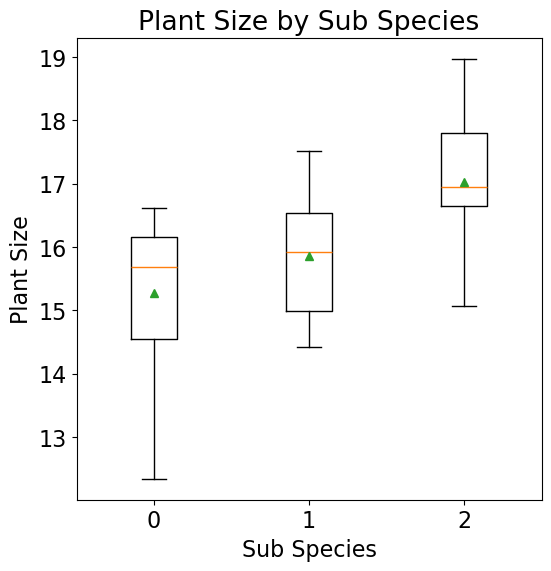

In [26]:
fig, ax = plt.subplots()
ax.boxplot(groups, tick_labels=['0', '1', '2'], showmeans=True)
ax.set_xlabel('Sub Species')
ax.set_ylabel('Plant Size')
ax.set_title('Plant Size by Sub Species')
plt.show()

We can then use a function `stats.tukey_hsd()` from `scipy` to calulcate the pair-wise comparisons:

In [27]:
hsd_res = stats.tukey_hsd(*groups)

print(hsd_res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.571     0.539    -1.890     0.748
 (0 - 2)     -1.741     0.008    -3.060    -0.423
 (1 - 0)      0.571     0.539    -0.748     1.890
 (1 - 2)     -1.171     0.089    -2.489     0.148
 (2 - 0)      1.741     0.008     0.423     3.060
 (2 - 1)      1.171     0.089    -0.148     2.489



The function returns a table with all possible combinations of groups. Note that each pair is there twice (in both directions). For each combination, the test statistic, p-value and confidence interval are calculated. The test statistic here simply corresponds to the difference of means between groups. If $0$ is inside this confidence interval (confidence by default is 95%, $\alpha = 0.05$), then we can say that there is no significant difference between this pair of groups, and the p-value would be higher than $0.05$; otherwise, the difference is significant, and we would reject the null hypothesis.

To visualise this, run this plotting script:

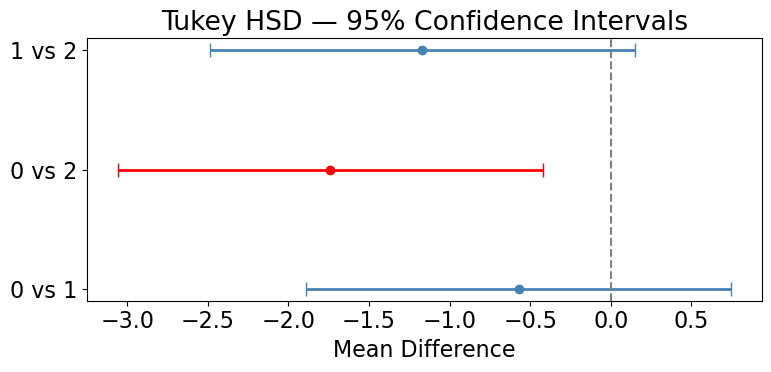

In [28]:
# defining pairs and labels
labels = ['0 vs 1', '0 vs 2', '1 vs 2']
pairs = [(0,1), (0,2), (1,2)]

# calculating confidence intervals, means, lows and highs of CI
ci = hsd_res.confidence_interval(confidence_level=0.95)
means  = [hsd_res.statistic[i][j] for i, j in pairs]
lows   = [ci.low[i][j]  for i, j in pairs]
highs  = [ci.high[i][j] for i, j in pairs]

# calculating error bars
err_low  = [m - l for m, l in zip(means, lows)]
err_high = [h - m for h, m in zip(highs, means)]

# defining colours, red means significant difference, blue not significant difference
colors = ['red' if l > 0 or h < 0 else 'steelblue' for l, h in zip(lows, highs)]

fig, ax = plt.subplots(figsize=(8,4))
for idx, (m, el, eh, c) in enumerate(zip(means, err_low, err_high, colors)):
    ax.errorbar(m, idx, xerr=[[el], [eh]], fmt='o', color=c, ecolor=c, elinewidth=2, capsize=5)

ax.axvline(0, color='grey', linestyle='--')
ax.set_yticks(range(len(pairs)))
ax.set_yticklabels(labels)
ax.set_xlabel('Mean Difference')
ax.set_title('Tukey HSD — 95% Confidence Intervals')
plt.tight_layout()
plt.show()

# Final Exercise 03

The dataset `'stcp-Rdataset-Diet.csv'` contains information on the weights 
of 78 test subjects spread among 3 types of diets.

Here is how to read the data:

In [29]:
df = pd.read_csv('data/stcp-Rdataset-Diet.csv')
df['weightDiff'] = df['weight6weeks'] - df['pre.weight']
df.describe()

,Person,Age,Height,pre.weight,Diet,weight6weeks,weightDiff
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,39.500000,39.153846,170.820513,72.525641,2.038462,68.680769,-3.844872
std,22.660538,9.815277,11.276621,8.723344,0.812920,8.924504,2.551478
min,1.000000,16.000000,141.000000,58.000000,1.000000,53.000000,-9.200000
25%,20.250000,32.250000,164.250000,66.000000,1.000000,61.850000,-5.550000
50%,39.500000,39.000000,169.500000,72.000000,2.000000,68.950000,-3.600000
75%,58.750000,46.750000,174.750000,78.000000,3.000000,73.825000,-2.000000
max,78.000000,60.000000,201.000000,103.000000,3.000000,103.000000,2.100000


In [30]:
df.Diet.value_counts()

Diet
2    27
3    27
1    24
Name: count, dtype: int64

Test if the diets are associated with a different weight difference on average. 
Be careful to test the assumptions of your test.


In [31]:
# First, a little plot to meet the data...
# Create a solution here:


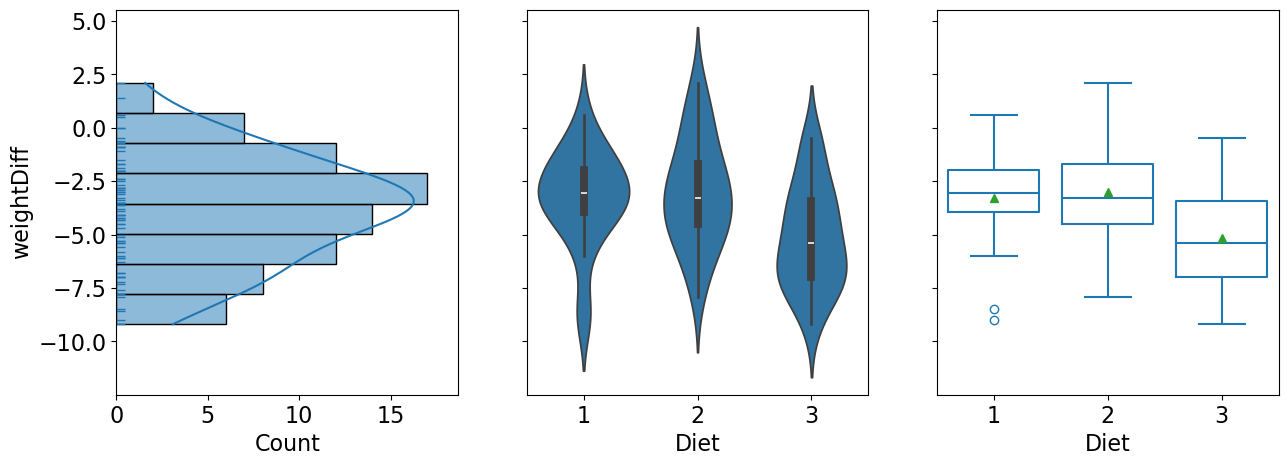

In [32]:
# %load -r 1-8 solutions/solution_03_03.py
## First, a little plot to meet the data:
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

sns.histplot(y=df['weightDiff'], kde=True, ax = axes[0])
sns.rugplot(y=df['weightDiff'], ax = axes[0])
sns.violinplot(x='Diet', y='weightDiff', data=df, ax = axes[1])
sns.boxplot(x='Diet', y='weightDiff', data=df, fill=False, showmeans=True, ax = axes[2])
plt.show()

In [33]:
# Test the assumptions for ANOVA...
# Create a solution here:


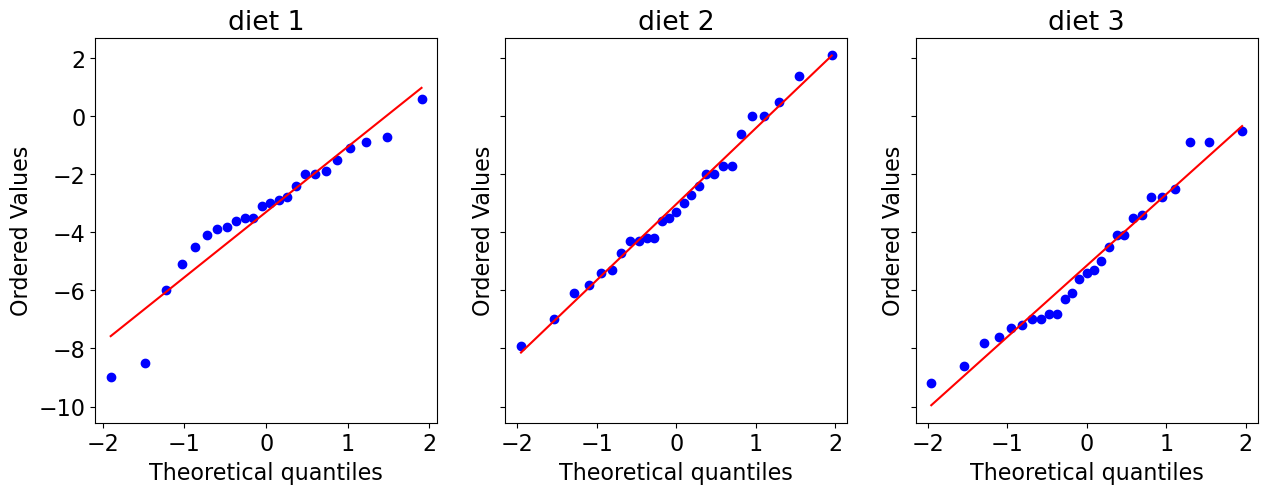

Checking the assumptions of ANOVA:
Shapiro-Wilk test of normality...
Diet
1    (0.9255313246138968, 0.07748633505906967)
2     (0.9855912340453256, 0.9611748496261021)
3     (0.9601254566120733, 0.3720400277004393)
Name: weightDiff, dtype: object
Bartlett test of homoscedasticity...
Statistic:  0.337454630479139
p-value:  0.8447392194944549


In [34]:
# %load -r 9-31 solutions/solution_03_03.py
## Test the assumptions for ANOVA:
# QQplots
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

# There are 3 levels of diet: 1, 2, and 3
for i, diet in enumerate([1,2,3]):
    stats.probplot(df.loc[df.Diet == diet, 'weightDiff'], plot=axes[i])
    axes[i].set_title("diet " + str(diet))
plt.show()

# Using groupby, we can apply the test function to each condition automatically:
print('Checking the assumptions of ANOVA:')

print('Shapiro-Wilk test of normality...')
print(df.groupby('Diet')['weightDiff'].apply(stats.shapiro))

print('Bartlett test of homoscedasticity...')
stat, pval = stats.bartlett(df['weightDiff'][df['Diet'] == 1], 
                            df['weightDiff'][df['Diet'] == 2],
                            df['weightDiff'][df['Diet'] == 3]
                           )
print('Statistic: ', stat)
print('p-value: ', pval)

In [35]:
# Perform the ANOVA test...
# Create a solution here:


In [36]:
# %load -r 32-48 solutions/solution_03_03.py
# The assumptions seem verified, we can perform the test:
groups = [
          df['weightDiff'][df['Diet'] == 1], 
          df['weightDiff'][df['Diet'] == 2],
          df['weightDiff'][df['Diet'] == 3]
]

Fstat, pval = stats.f_oneway(*groups)

print('Automated One-way ANOVA / F-test:')
print('F-stat: ', Fstat)
print('p-value: ', pval)

if pval < 0.05:
    # statistical significance should be accompanied by actual effect size:
    print('Mean weightloss per group:')
    print(df.groupby('Diet')['weightDiff'].mean())

Automated One-way ANOVA / F-test:
F-stat:  6.197447453165349
p-value:  0.0032290142385893628
Mean weightloss per group:
Diet
1   -3.300000
2   -3.025926
3   -5.148148
Name: weightDiff, dtype: float64


In [37]:
# Perform the Tukey's HSD test...
# Create a solution here:


Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.274     0.912    -1.881     1.332
 (0 - 2)      1.848     0.020     0.242     3.455
 (1 - 0)      0.274     0.912    -1.332     1.881
 (1 - 2)      2.122     0.005     0.564     3.681
 (2 - 0)     -1.848     0.020    -3.455    -0.242
 (2 - 1)     -2.122     0.005    -3.681    -0.564



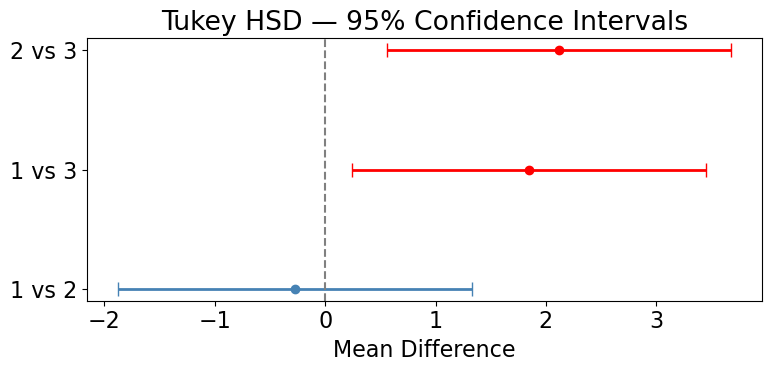

In [38]:
# %load -r 49- solutions/solution_03_03.py
# ANOVA showed a significant result, so we can now perform Tukey's HSD:
hsd_res = stats.tukey_hsd(*groups)

print(hsd_res)

labels = ['1 vs 2', '1 vs 3', '2 vs 3']
pairs = [(1,2), (1,3), (2,3)]

ci = hsd_res.confidence_interval(confidence_level=0.95)
means  = [hsd_res.statistic[i-1][j-1] for i, j in pairs]
lows   = [ci.low[i-1][j-1]  for i, j in pairs]
highs  = [ci.high[i-1][j-1] for i, j in pairs]

err_low  = [m - l for m, l in zip(means, lows)]
err_high = [h - m for h, m in zip(highs, means)]

colors = ['red' if l > 0 or h < 0 else 'steelblue' for l, h in zip(lows, highs)]

fig, ax = plt.subplots(figsize=(8,4))
for idx, (m, el, eh, c) in enumerate(zip(means, err_low, err_high, colors)):
    ax.errorbar(m, idx, xerr=[[el], [eh]], fmt='o', color=c, ecolor=c, elinewidth=2, capsize=5)

ax.axvline(0, color='grey', linestyle='--')
ax.set_yticks(range(len(pairs)))
ax.set_yticklabels(labels)
ax.set_xlabel('Mean Difference')
ax.set_title('Tukey HSD — 95% Confidence Intervals')
plt.tight_layout()
plt.show()

**Bonus exercise :** go back to the 1880 swiss census data. Is the main language spoken in a locality linked to the total number of inhabitant in town ?

In [39]:
# Create a solution here:
